<a href="https://colab.research.google.com/github/gibranfp/CursoAprendizajeProfundo/blob/2026-1/notebooks/5d_dcgan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generación de imágenes mediante DCGAN
En esta libreta se programa y entrena una red generativa adversaria convolucional profundo (DCGAN) para la generación de imágenes de rostros.

In [1]:
from math import sqrt, floor, ceil

import numpy as np
import matplotlib.pyplot as plt

import torch as th
from torch import nn
from torch.utils.data import DataLoader

import torchvision as tv
import torchvision.transforms as T

N_MUESTRAS_IMG = 32
FREQ_GENVIS = 2
N_EPOCAS = 10

# valores de hiperparámtros sugeridos en artículo de DCGAN
IMG_SIZE = 64
N_CANALES = 1024
T_LOTE = 128
T_EMB = 100
LR = 0.0002
BETA1 = 0.5

DC = th.device('cuda:0' if th.cuda.is_available() else 'cpu')

np.random.seed(42)
th.manual_seed(42)

## Conjunto de imágenes
Se instancia la clase predefinida en `torchvision` del conjunto de imágenes de rostros CelebA, redimensionando las imágenes, convirtiéndolas a `Tensor` y escalando sus valores a un rango de $-1$ a $1$.

Previamente, debes descargar el archivo ZIP, subirlo y extraerlo en `./celeba/`:

https://drive.usercontent.google.com/download?id=1m8-EBPgi5MRubrm6iQjafK2QMHDBMSfJ&export=download&authuser=1&confirm=t&uuid=44e800de-90ee-4230-a19d-3e80f26ae0f1&at=ALWLOp5_x4PUa9beUUBqJgLQQMgt%3A1763570965949

In [2]:
tr = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE),
                         antialias = True),
                T.ToTensor(),
                T.Normalize(mean = (0.5, 0.5, 0.5),
                            std = (0.5, 0.5, 0.5))])
ds = tv.datasets.CelebA(root = './',
                        split = 'all',
                        download = False,
                        transform = tr)
dl = DataLoader(ds,
                batch_size = T_LOTE,
                shuffle = True,
                drop_last = True,
                num_workers = 4)

it_dl = iter(dl)
lote = next(it_dl)
print(f'Imágenes = {lote[0].shape}, Categorías = {lote[1].shape}')

Imágenes = torch.Size([128, 3, 64, 64]), Categorías = torch.Size([128, 40])


Se crea una función para visualizar una rejilla de imágenes.

In [3]:
def muestra_imagenes(imgs):
  t_muestra = imgs.shape[0]
  n_filas = floor(sqrt(t_muestra))
  n_cols = ceil(sqrt(t_muestra))

  fig, ax = plt.subplots(nrows = n_filas, ncols = n_cols)

  for i in range(n_filas):
    for j in range(n_cols):
      idx = i * n_filas + j
      ax[i, j].imshow(imgs[idx])
      ax[i, j].axis('off')

  fig.subplots_adjust(wspace=-0.5, hspace=0)
  plt.show()

Mostramos un lote del conjunto de datos.

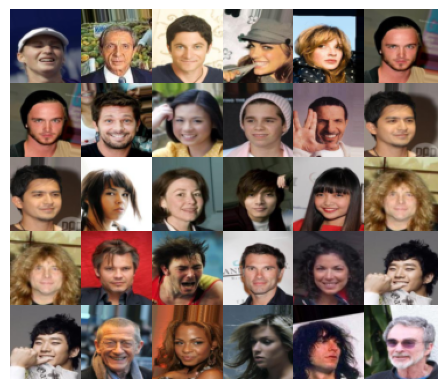

In [4]:
muestra_imagenes(lote[0][:N_MUESTRAS_IMG].permute(0, 2, 3, 1).numpy() * 0.5 + 0.5)

### Arquitectura de DCGAN
El vector de entrada ($z$) al generador se proyecta mediante una capa lineal, cuya salida se pasa por una capa de normalización por lotes y se redimensiona para formar un mapa de $4 \times 4 \times C$, donde $C$ es el número de canales inicial. Este mapa se procesa de forma secuencial por capas de convoluciones transpuestas seguidas por capas de normalización por lotes, excepto en la última capa de convolución transpuesta. Después de cada capa de normalización por lotes se aplica la función de activación ReLU, mientras que en la  última convolución transpuesta se aplica una función de activación tangente hiperbólica.

In [5]:
class Generador(nn.Module):
  def __init__(self,
               t_emb,
               nf = 1024):
    super(Generador, self).__init__()

    self.nf = nf
    self.t_emb = t_emb

    self.proj = nn.Linear(t_emb, 4 * 4 * nf, bias = False)
    self.bn_proj = nn.BatchNorm1d(4 * 4 * nf)

    self.bloque1 = nn.Sequential(nn.ConvTranspose2d(nf, nf // 2, 4, 2, 1, bias = False),
                                 nn.BatchNorm2d(nf // 2))
    self.bloque2 = nn.Sequential(nn.ConvTranspose2d(nf // 2, nf // 4, 4, 2, 1, bias = False),
                                 nn.BatchNorm2d(nf // 4))
    self.bloque3 = nn.Sequential(nn.ConvTranspose2d(nf // 4, nf // 8, 4, 2, 1, bias = False),
                                 nn.BatchNorm2d(nf // 8))
    self.output = nn.ConvTranspose2d(nf // 8, 3, 4, 2, 1, bias = False)

  def forward(self, x):
    x = self.proj(x)
    x = nn.functional.relu(self.bn_proj(x))
    x = x.reshape(-1, self.nf, 4, 4)

    x = nn.functional.relu(self.bloque1(x))
    x = nn.functional.relu(self.bloque2(x))
    x = nn.functional.relu(self.bloque3(x))
    x = nn.functional.tanh(self.output(x))

    return x

Definimos función para generar muestras con la red generadora.

In [6]:
def genera_imagenes(gen, n_imagenes, t_emb, disp):
  gen.eval()
  with th.no_grad():
    # muestreamos vectores latentes
    Z = th.rand((n_imagenes, t_emb), device = disp)

    # generamos imágenes a partir de vectores latentes muestreados
    X_gen = gen(Z)

    # cambiamos posición de canales de las imágenes generadas, las pasamos
    # al CPU y normalizamos sus valores
    X_gen = X_gen.permute(0, 2, 3, 1).cpu().numpy() * 0.5 + 0.5

    return X_gen


El discriminador tiene una arquitectura estándar de red convolucional, compuesta por capas convolucionales seguidas por capas de normalización por lotes y funciones de activación Leaky ReLU. El mapa de características resultantes de las capas anteriores se convierte a un vector para finalmente pasarlo por una sola neurona sigmoide.

In [7]:
class Discriminador(nn.Module):
  def __init__(self,
               nf = 1024):
    super(Discriminador, self).__init__()

    self.conv1 = nn.Conv2d(3, nf // 8, 4, 2, 1, bias = False)
    self.bn1 = nn.BatchNorm2d(nf // 8)
    self.conv2 = nn.Conv2d(nf // 8, nf // 4, 4, 2, 1, bias = False)
    self.bn2 = nn.BatchNorm2d(nf // 4)
    self.conv3 = nn.Conv2d(nf // 4, nf // 2, 4, 2, 1, bias = False)
    self.bn3 = nn.BatchNorm2d(nf // 2)
    self.conv4 = nn.Conv2d(nf // 2, nf, 4, 2, 1, bias = False)
    self.bn4 = nn.BatchNorm2d(nf)

    self.output = nn.Linear(nf * 4 * 4, 1, bias = False)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = nn.functional.leaky_relu(x, negative_slope = 0.2)

    x = self.conv2(x)
    x = self.bn2(x)
    x = nn.functional.leaky_relu(x, negative_slope = 0.2)

    x = self.conv3(x)
    x = self.bn3(x)
    x = nn.functional.leaky_relu(x, negative_slope = 0.2)

    x = self.conv4(x)
    x = self.bn4(x)
    x = nn.functional.leaky_relu(x, negative_slope = 0.2)

    x = self.output(x.flatten(start_dim = 1))
    return x

En el artículo de DCGAN ([Radford et al. 2016](https://arxiv.org/abs/1511.06434])), se menciona que todos los pesos se inicializan a partir de una distribución Normal con media de 0 y desviación estándar de 0.02. Para llevar a cabo esto, definimos la siguiente función:

In [8]:
def weights_init(m):
  classname = m.__class__.__name__
  if classname.find('Conv') != -1:
    nn.init.normal_(m.weight.data, 0.0, 0.02)
  elif classname.find('BatchNorm') != -1:
    nn.init.normal_(m.weight.data, 1.0, 0.02)
    nn.init.constant_(m.bias.data, 0)

## Función de pérdida
La función de pérdida empleada está dada por

$$
\begin{align*}
  \mathcal{L}_{{D}} = & -\frac{1}{2} \mathbb{E}_{\mathbf{x}}\left[\log \{ {{D}_{\boldsymbol{\Theta}}}(\mathbf{x})\}\right] - \frac{1}{2} \mathbb{E}_\mathbf{z} \left[\log \{1-{D}_{\boldsymbol{\Theta}}({G}_{\boldsymbol{\Phi}}(\mathbf{z}))\}\right]\\
  \mathcal{L}_{{G}} = & - \frac{1}{2} \mathbb{E}_\mathbf{z} \left[\log\{{D}_{\boldsymbol{\Theta}}({G}_{\boldsymbol{\Phi}}(\mathbf{z}))\}\right]
\end{align*}
$$

donde $\boldsymbol{\Theta}$ y $\boldsymbol{\Phi}$ son los parámetros del discriminador y del generador, respectivamente.

In [9]:
class PerdidaGAN:
  def __init__(self):
    self.ecc = nn.BCEWithLogitsLoss()

  def gen(self, falsas):
    return self.ecc(falsas, th.ones_like(falsas))

  def dis(self, reales, falsas):
    perdida_real = self.ecc(reales, th.ones_like(reales))
    perdida_falsa = self.ecc(falsas, th.zeros_like(falsas))
    return perdida_real + perdida_falsa

## Funciones para el entrenamiento
Para facilitar el entrenamiento, definimos diversas funciones.

### Registrar información para Tensorboard
Para guardar información que pueda visualizarse con Tensorboard, instanciamos la clase `SummaryWriter` del submódulo `tensorboard` del módulo `utils` y escribimos información mediante los distintos métodos disponibles (por ej. `add_scalar`, `add_image`, `add_histogram`, etc.).

In [10]:
from torch.utils.tensorboard import SummaryWriter

def registra_info_tboard(writer, epoca, hist):
  for (m,v) in hist.items():
    writer.add_scalar(m, v[epoca], epoca)

### Paso de entrenamiento
Definimos una función que realiza un paso de entrenamiento, a la cual llamaremos `paso_ent`. Esta función recibe como argumentos:
- El generador como una instancia de `Module` (`gen`).
- El discriminador como una instancia de `Module` (`dis`).
- La función de pérdida como instancia de `PerdidaGAN` (`fp`).
- Una instancia de `Optimizer` del módulo `optim` de PyTorch para actualizar los pesos y sesgos del generador (`opt_gen`).
- Una instancia de `Optimizer` del módulo `optim` de PyTorch para actualizar los pesos y sesgos del discriminador (`opt_dis`).
- Una instancia de `Tensor` con el lote de entradas (`X`).

Para cada paso de entrenamiento, se realiza lo siguiente:

1. Se carga un lote de imágenes reales.
2. Se genera un lote de imágenes generadas.
3. Se pasa por el discriminador el lote de imágenes reales
4. Se pasa por el discriminador el lote de imágenes generadas desconectadas del grafo de cómputo debido a que no se van a obtener los gradientes respecto al generador.
5. Se calcula la pérdida del discriminador.
6. Se obtienen los gradientes de la pérdida respecto a los parámetros del discriminador.
7. Se pasa por el discriminador el lote de imágenes generadas conectadas al grafo de cómputo.
8. Se calcula la pérdida del generador.
9. Se obtienen los gradientes de la pérdida respecto a los parámetros del generador.
10. Se actualizan los parámetros tanto el discriminador como el generador.  

In [11]:
def paso_ent(gen,
             dis,
             fp,
             opt_gen,
             opt_dis,
             X):
    # ponemos parámetros de generador y discriminador
    # en zero
    opt_dis.zero_grad()
    opt_gen.zero_grad()

    # muestreamos vectores latentes
    Z = th.rand((T_LOTE, T_EMB), device = X.device)

    # generamos imágenes con vectores latentes
    X_gen = gen(Z)

    # desconectamos imágenes generadas de grafo de cómputo para evitar que
    # se intenten calcular gradientes de generador al calcular los gradientes
    # del discriminador
    X_gen_detached = X_gen.detach()

    # obtenemos salidas del discriminador para el lote de imágenes reales
    reales = dis(X).view(-1)

    # obtenemos salidas del discriminador para el lote de imágenes generadas
    # desconectadas del grafo de cómputo
    falsas_detached = dis(X_gen_detached).view(-1)

    # calculamos la pérdida del discriminador y sus gradientes
    perdida_dis = fp.dis(reales, falsas_detached)
    perdida_dis.backward()

    # obtenemos salidas del discriminador para imágenes generadas, pero con
    # las que no están desconectadas del grafo de cómputo para calcular los
    # gradientes de la pérdida respecto a los parámetros del generador
    falsas = dis(X_gen).view(-1)

    # calculamos la pérdida del generador y sus gradientes
    perdida_gen = fp.gen(falsas)
    perdida_gen.backward()

    # actualizamos tanto generador como discriminador
    # a partir de los gradientes calculados
    opt_dis.step()
    opt_gen.step()

    with th.no_grad():
      perdida_gen_paso = perdida_gen.cpu().item()
      perdida_dis_paso = perdida_dis.cpu().item()

    return perdida_gen_paso, perdida_dis_paso

### Función para el ciclo principal de entrenamiento
También definimos el ciclo de entrenamiento principal, que llamaremos `entrena`. Esta función recibe como argumentos:
- El generador como una instancia de `Module` (`gen`).
- El discriminador como una instancia de `Module` (`dis`).
- La función de pérdida como instancia de `PerdidaGAN` (`fp`).
- Una instancia de `Optimizer` del módulo `optim` de PyTorch para actualizar los pesos y sesgos del generador (`opt_gen`).
- Una instancia de `Optimizer` del módulo `optim` de PyTorch para actualizar los pesos y sesgos del discriminador (`opt_dis`).
- El cargador de datos del subconjunto de entrenamiento (`dl`).
- El número de épocas de entrenamiento (`n_epocas`).
- El dispositivo en el que se ejecutará el modelo (`disp`).
- Cada cuántas épocas generar y guardar imágenes de ejemplo con el modelo (`freq_vis`)
- La ruta al directorio donde se guardará la información para Tensorboard (`tbdir`).

Para cada una de las épocas, va tomando un lote de entradas y salidas a la vez, con los cuales se realiza un paso de entrenamiento.

In [12]:
def entrena(gen,
            dis,
            fp,
            opt_gen,
            opt_dis,
            dl,
            n_epocas,
            disp,
            freq_vis = 5,
            tbdir = 'runs/'):

  hist = {
          'perdida_gen': np.zeros(n_epocas),
          'perdida_dis': np.zeros(n_epocas)

  }

  tbwriter = SummaryWriter(tbdir)

  lst_img_gen = []
  for e in range(n_epocas):

    gen.train()
    dis.train()
    for X,_ in dl:
      X = X.to(disp)
      perdida_paso_gen, perdida_paso_dis = paso_ent(gen,
                                                    dis,
                                                    fp,
                                                    opt_gen,
                                                    opt_dis,
                                                    X)
      hist['perdida_gen'][e] += perdida_paso_gen
      hist['perdida_dis'][e] += perdida_paso_dis

    registra_info_tboard(tbwriter, e, hist)

    print(f'Época {e}/{n_epocas}: '
          f'Pérdida G = {hist["perdida_gen"][e]:.3f}, '
          f'Pérdida D = {hist["perdida_dis"][e]:.3f}')

    # guarda imágenes generadas con el modelo cada cierto número de épocas
    if e % freq_vis == 0:
      X_gen = genera_imagenes(gen, N_MUESTRAS_IMG, T_EMB, disp)
      lst_img_gen.append(X_gen)

  return gen, dis, hist, lst_img_gen

## Entrenamiento
Se instancia un optimizador para el generador, otro más para el discriminador y la función de pérdida y se entrena la GAN.

In [13]:
gen = Generador(T_EMB, N_CANALES).apply(weights_init)
dis = Discriminador(N_CANALES).apply(weights_init)


opt_gen = th.optim.Adam(gen.parameters(),
                        lr = LR, betas = (BETA1, 0.999))
opt_dis = th.optim.Adam(dis.parameters(),
                        lr = LR, betas = (BETA1, 0.999))

fp = PerdidaGAN()

gen.to(DC)
dis.to(DC)
gen, dis, hist, lst_img_gen = entrena(gen,
                                      dis,
                                      fp,
                                      opt_gen,
                                      opt_dis,
                                      dl,
                                      N_EPOCAS,
                                      DC,
                                      FREQ_GENVIS,
                                      tbdir = './runs')


Época 0/10: Pérdida G = 977.680, Pérdida D = 1829.938
Época 1/10: Pérdida G = 897.613, Pérdida D = 1855.332
Época 2/10: Pérdida G = 895.425, Pérdida D = 1855.334
Época 3/10: Pérdida G = 873.439, Pérdida D = 1903.976
Época 4/10: Pérdida G = 873.558, Pérdida D = 1902.242
Época 5/10: Pérdida G = 888.147, Pérdida D = 1868.388
Época 6/10: Pérdida G = 906.467, Pérdida D = 1811.264
Época 7/10: Pérdida G = 923.557, Pérdida D = 1776.072
Época 8/10: Pérdida G = 941.606, Pérdida D = 1724.077
Época 9/10: Pérdida G = 960.287, Pérdida D = 1676.151


Se grafican la pérdida del generador y del discriminador.

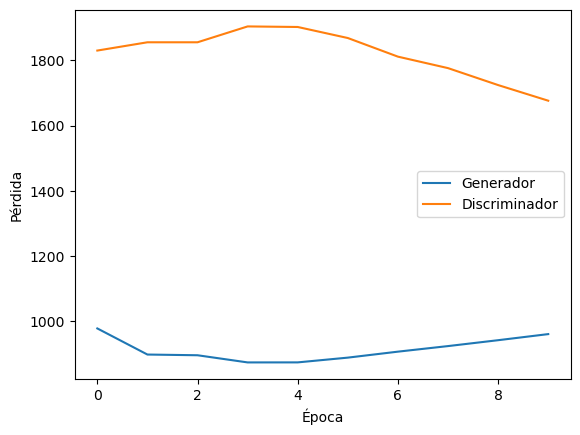

In [14]:
plt.plot(hist['perdida_gen'], label = 'Generador')
plt.plot(hist['perdida_dis'], label = 'Discriminador')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

Visualizamos los lotes de imágenes generadas guardadas.

Época 1


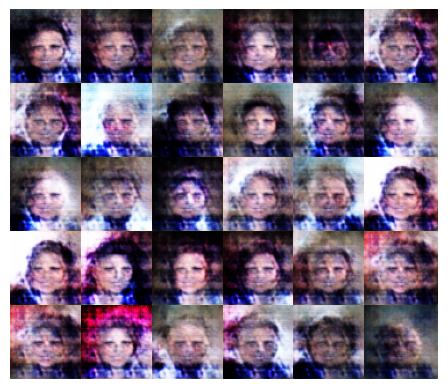

Época 3


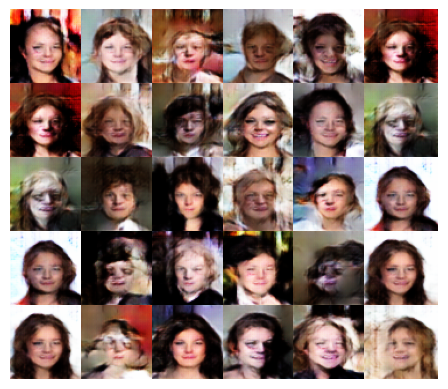

Época 5


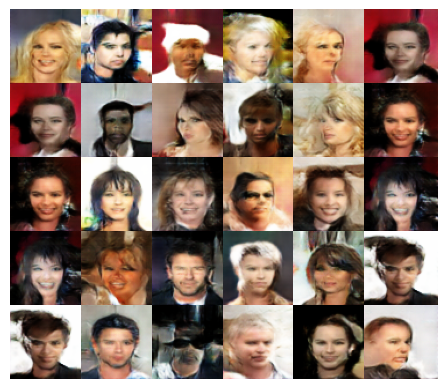

Época 7


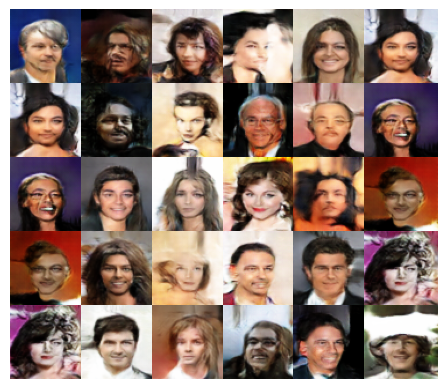

Época 9


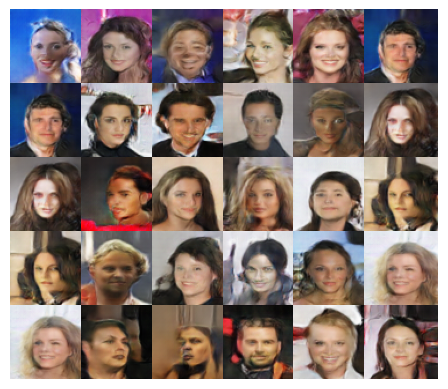

In [15]:
for e,imgs in enumerate(lst_img_gen):
  print(f'Época {e * FREQ_GENVIS + 1}')
  muestra_imagenes(imgs)